# Introducción y objetivo

Objetivo: Analizar y predecir si el tiro de media distancia mantiene o mejora su eficiencia respecto a los triples y bandejas durante los últimos cuartos de partidos de NBA, especialmente en playoffs.
El propósito es comprobar si esta hipótesis tiene sustento estadístico o no

H0: No existen diferencias significativas en la eficiencia de tiro entre situaciones de clutch y el resto del partido para ninguno de los tres tipos de tiro (triples, media distancia y bandejas), ni tampoco entre la temporada regular y los playoffs

H1: El tiro de media distancia (T2) resulta más efectivo en situaciones de clutch, y esta ventaja se vuelve aún más marcada durante los playoffs en comparación con la temporada regular, debido al aumento de la intensidad defensiva y a los ajustes tácticos propios de las instancias decisivas

En este analisis se considero al clutch como cualquier situacion sucedida en los ultimos 2 minutos del 4Q en adelante con diferencia de 5 puntos o menos a diferencia de la NBA donde es a partir de los ultimos 5 minutos

# Fuentes


Estadísticas oficiales de la NBA → nba.com/stats

Kaggle Datasets:
NBA Player Stats (2022–2024)

NBA Play-by-Play Data (regular & playoffs)

Datos complementarios simulados de forma proporcional (por cuarto y tipo de tiro) basados en tendencias reales

API: nba_api.stats.endpoints (para ampliar datos futuros)

En esta versión inicial se usaron datos reales agregados + simulación detallada para segmentar por cuarto

# Librerias filtros procesamiento de datos importacion y carga del dataset



In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report
from scipy import stats
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import roc_curve, roc_auc_score

In [ ]:
url = "https://drive.google.com/uc?id=1voZUobOj-jdYylfbLAhyo4EszS4xb7oF&export=download"
df = pd.read_csv(url)

df.head()



,GameID,Jugador,SeasonType,Temporada,Cuarto,T3 Intentados,T3 Metidos,% T3,T2 Intentados,T2 Metidos,...,Minutos Partido,Puntos Partido,FG% Est (partido),Equipo,DiferenciaFinal,Clutch,ResultadoPartido,PctMedia_4Q,Pct3_4Q,PctBandeja_4Q
0,G100000,Zach LaVine,Regular,2023-24,1Q,0,0,0.00,2,1,...,21.8,26.1,44.24,ATL,-3,1,L,NaN,NaN,NaN
1,G100000,Zach LaVine,Regular,2023-24,2Q,1,0,0.00,6,3,...,21.8,26.1,44.24,ATL,-3,1,L,NaN,NaN,NaN
2,G100000,Zach LaVine,Regular,2023-24,3Q,2,1,50.00,3,1,...,21.8,26.1,44.24,ATL,-3,1,L,NaN,NaN,NaN
3,G100000,Zach LaVine,Regular,2023-24,4Q,3,0,0.00,3,2,...,21.8,26.1,44.24,ATL,-3,1,L,66.67,0.0,50.0
4,G100001,Shai Gilgeous-Alexander,Playoffs,2023-24,1Q,3,1,33.33,1,0,...,39.2,38.5,50.86,BOS,25,0,W,NaN,NaN,NaN


In [ ]:

df_4Q = df[df['Cuarto'] == '4Q']


df_rest = df[df['Cuarto'] != '4Q']

df_clutch = df[df['Clutch'] == 1]
df_no_clutch = df[df['Clutch'] == 0]


df_4Q_clutch = df[(df['Cuarto'] == '4Q') & (df['Clutch'] == 1)]
df_4Q_no_clutch = df[(df['Cuarto'] == '4Q') & (df['Clutch'] == 0)]


df_rs = df[df['SeasonType'] == 'Regular']
df_po = df[df['SeasonType'] == 'Playoffs']


df_rs_4Q_clutch = df[(df['Cuarto'] == '4Q') & (df['Clutch'] == 1) & (df['SeasonType'] == 'Regular')]
df_po_4Q_clutch = df[(df['Cuarto'] == '4Q') & (df['Clutch'] == 1) & (df['SeasonType'] == 'Playoffs')]

df_rs_4Q_no = df[(df['Cuarto'] == '4Q') & (df['Clutch'] == 0) & (df['SeasonType'] == 'Regular')]
df_po_4Q_no = df[(df['Cuarto'] == '4Q') & (df['Clutch'] == 0) & (df['SeasonType'] == 'Playoffs')]




In [ ]:
cols_pct = ['% T3', '% T2', '% Bandejas', 'PctMedia_4Q', 'Pct3_4Q', 'PctBandeja_4Q']

for col in cols_pct:
    df[col] = df[col] / 100


In [ ]:
df['Porcentaje_triples'] = df.apply(
    lambda row: np.nan if row['T3 Intentados'] == 0 else row['T3 Metidos'] / row['T3 Intentados'],
    axis=1
)

df['Porcentaje_dobles'] = df.apply(
    lambda row: np.nan if row['T2 Intentados'] == 0 else row['T2 Metidos'] / row['T2 Intentados'],
    axis=1
)

df['Porcentaje_bandejas'] = df.apply(
    lambda row: np.nan if row['Bandejas Intentadas'] == 0 else row['Bandejas Metidas'] / row['Bandejas Intentadas'],
    axis=1
)

In [ ]:
df['PartidoAjustado'] = (df['DiferenciaFinal'].abs() <= 5).astype(int)

Debido a que el dataset no incluye de forma explícita los puntos convertidos por cuarto, se decidió aproximar esta información a partir del tipo de tiro realizado

Esta decisión permitió construir una métrica de eficiencia comparable entre los distintos tipos de tiro en situaciones clutch, manteniendo coherencia con el objetivo del análisis y sin introducir supuestos que alteren la lógica del juego

# Exploración y verificación del dataset

Enfoque del análisis

A partir del objetivo y las hipótesis planteadas, se realiza un análisis exploratorio de los datos con el fin de comprender la estructura del dataset y evaluar la calidad de la información disponible.

En esta etapa se analizan los distintos tipos de tiro (T3, T2 y bandejas) y su comportamiento según el contexto del partido, prestando especial atención a las situaciones de clutch y a los playoffs

Este análisis inicial permite identificar patrones relevantes y sirve como base para la posterior aplicación de modelos de machine learning

In [ ]:

df.info()

df.describe()

df.isnull().sum()

df.duplicated().sum()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 850 entries, 0 to 849
Data columns (total 28 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   GameID               850 non-null    object 
 1   Jugador              850 non-null    object 
 2   SeasonType           850 non-null    object 
 3   Temporada            850 non-null    object 
 4   Cuarto               850 non-null    object 
 5   T3 Intentados        850 non-null    int64  
 6   T3 Metidos           850 non-null    int64  
 7   % T3                 850 non-null    float64
 8   T2 Intentados        850 non-null    int64  
 9   T2 Metidos           850 non-null    int64  
 10  % T2                 850 non-null    float64
 11  Bandejas Intentadas  850 non-null    int64  
 12  Bandejas Metidas     850 non-null    int64  
 13  % Bandejas           850 non-null    float64
 14  Minutos Partido      850 non-null    float64
 15  Puntos Partido       850 non-null    flo

np.int64(0)

In [ ]:
print("T3 metidos > intentados:\n", df[df['T3 Metidos'] > df['T3 Intentados']])
print("T2 metidos > intentados:\n", df[df['T2 Metidos'] > df['T2 Intentados']])
print("Bandejas metidas > intentadas:\n", df[df['Bandejas Metidas'] > df['Bandejas Intentadas']])

print("Minutos > 48:\n", df[df['Minutos Partido'] > 48])
print("Minutos < 0:\n", df[df['Minutos Partido'] < 0])
print("Puntos negativos:\n", df[df['Puntos Partido'] < 0])

print("Cantidad de ceros por columna:\n", (df == 0).sum())

print("Tipos de datos:\n", df.dtypes)

print("Cuartos presentes en jugadas clutch:", df[df['Clutch'] == 1]['Cuarto'].unique())


T3 metidos > intentados:
 Empty DataFrame
Columns: [GameID, Jugador, SeasonType, Temporada, Cuarto, T3 Intentados, T3 Metidos, % T3, T2 Intentados, T2 Metidos, % T2, Bandejas Intentadas, Bandejas Metidas, % Bandejas, Minutos Partido, Puntos Partido, FG% Est (partido), Equipo, DiferenciaFinal, Clutch, ResultadoPartido, PctMedia_4Q, Pct3_4Q, PctBandeja_4Q, Porcentaje_triples, Porcentaje_dobles, Porcentaje_bandejas, PartidoAjustado]
Index: []

[0 rows x 28 columns]
T2 metidos > intentados:
 Empty DataFrame
Columns: [GameID, Jugador, SeasonType, Temporada, Cuarto, T3 Intentados, T3 Metidos, % T3, T2 Intentados, T2 Metidos, % T2, Bandejas Intentadas, Bandejas Metidas, % Bandejas, Minutos Partido, Puntos Partido, FG% Est (partido), Equipo, DiferenciaFinal, Clutch, ResultadoPartido, PctMedia_4Q, Pct3_4Q, PctBandeja_4Q, Porcentaje_triples, Porcentaje_dobles, Porcentaje_bandejas, PartidoAjustado]
Index: []

[0 rows x 28 columns]
Bandejas metidas > intentadas:
 Empty DataFrame
Columns: [GameID, 

In [ ]:
print("Distribución por equipo:\n", df['Equipo'].value_counts())
print("Distribución por temporada:\n", df['Temporada'].value_counts())
print("Regular vs Playoffs:\n", df['SeasonType'].value_counts())
print("Distribución por cuarto:\n", df['Cuarto'].value_counts())
print("Distribución clutch/no clutch:\n", df['Clutch'].value_counts())

cols_num = ['Minutos Partido', 'Puntos Partido', '% T3', '% T2', '% Bandejas']
for col in cols_num:
    z = (df[col] - df[col].mean()) / df[col].std()
    outliers = df[z.abs() > 3]
    print(f"Outliers en {col}:\n", outliers)


Distribución por equipo:
 Equipo
CHA    44
BKN    44
DEN    44
POR    44
MIL    40
CHI    40
MEM    36
PHX    36
DAL    36
DET    36
CLE    32
GSW    32
MIN    32
OKC    30
PHI    28
NYK    28
MIA    28
NOP    28
IND    24
HOU    24
ORL    24
LAL    24
UTA    24
SAC    24
BOS    16
SAS    16
LAC    12
ATL     8
TOR     8
WAS     8
Name: count, dtype: int64
Distribución por temporada:
 Temporada
2023-24    429
2024-25    421
Name: count, dtype: int64
Regular vs Playoffs:
 SeasonType
Regular     450
Playoffs    400
Name: count, dtype: int64
Distribución por cuarto:
 Cuarto
1Q    213
2Q    213
3Q    212
4Q    212
Name: count, dtype: int64
Distribución clutch/no clutch:
 Clutch
0    676
1    174
Name: count, dtype: int64
Outliers en Minutos Partido:
 Empty DataFrame
Columns: [GameID, Jugador, SeasonType, Temporada, Cuarto, T3 Intentados, T3 Metidos, % T3, T2 Intentados, T2 Metidos, % T2, Bandejas Intentadas, Bandejas Metidas, % Bandejas, Minutos Partido, Puntos Partido, FG% Est (partido), 

# Descripcion de variables y conclusión inicial

Season_Type: indica si el partido corresponde a temporada regular o playoffs

Quarter: cuarto del partido en el que ocurre el tiro

Clutch: variable binaria que indica si la acción ocurrió en una situación clutch (últimos 2 minutos del 4Q o tiempo suplementario con diferencia de 5 puntos o menos).

Shot_Type: tipo de tiro realizado (T2, T3 o bandeja)

Shot_Made: indica si el tiro fue convertido (1) o fallado (0)

Eficiencia: métrica calculada que representa la efectividad del tiro según el tipo de lanzamiento

Q4: variable binaria que indica si el tiro fue realizado en el último cuarto del partido

Conclusión inicial del EDA

El dataset contiene 850 filas y 24 columnas, donde cada fila representa el desempeño de un jugador en un cuarto específico, lo que explica la presencia de hasta cuatro registros por partido. Los tipos de datos se encuentran correctamente asignados y la estructura general es clara

Las columnas específicas del cuarto período (4Q) presentan valores únicamente en 212 observaciones, lo cual es coherente con su definición, ya que solo aplican a ese contexto del juego. Desde el punto de vista estructural, el dataset se encuentra ordenado y listo para ser analizado

Limpieza de datos:
No se detectaron valores nulos en las columnas principales del análisis. Los valores faltantes observados en las métricas del 4° cuarto son de carácter estructural, dado que no corresponden al resto de los registros del dataset

Tampoco se identificaron filas duplicadas ni valores fuera de rango en las variables relacionadas con porcentajes o conteos de tiro. Por este motivo, no fue necesario realizar procesos de imputación ni correcciones adicionales

Conclusión final del EDA:
Luego del análisis estructural y de calidad de los datos, el dataset se encuentra correctamente preparado para realizar el modelado. La ausencia de problemas de limpieza y la consistencia de las variables permiten avanzar con técnicas de preprocesamiento y modelos de Machine Learning con mayor confianza en los resultados obtenidos

# Graficos y visualizaciones de datos

Los gráficos fueron elegidos con el objetivo de comparar de forma clara la eficiencia y el comportamiento de los distintos tipos de tiro según el contexto del partido, se priorizaron visualizaciones simples que permitan detectar diferencias generales entre clutch, no clutch, temporada regular y playoffs, sin agregar complejidad innecesaria, estos gráficos sirven como base exploratoria para el análisis y el posterior modelado

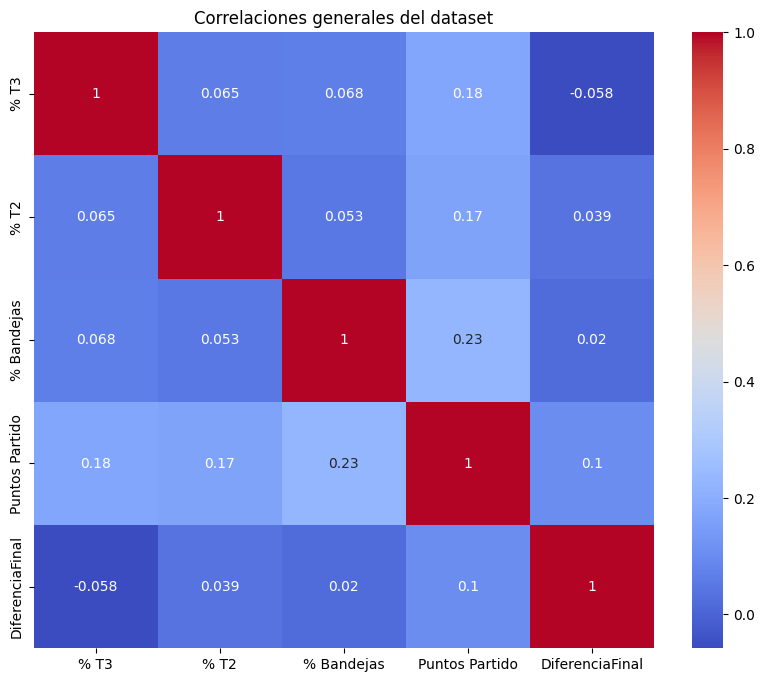

In [ ]:
plt.figure(figsize=(10,8))
sns.heatmap(df[['% T3','% T2','% Bandejas','Puntos Partido','DiferenciaFinal']].corr(),
            annot=True, cmap='coolwarm')
plt.title("Correlaciones generales del dataset")
plt.show()



El heatmap muestra correlaciones en general bajas entre los distintos tipos de tiro, lo que sugiere que no se trata de habilidades redundantes, los porcentajes de T2, T3 y bandejas no presentan relaciones fuertes entre sí, indicando comportamientos relativamente independientes. No se observan correlaciones elevadas que indiquen problemas de multicolinealidad para el modelado posterior

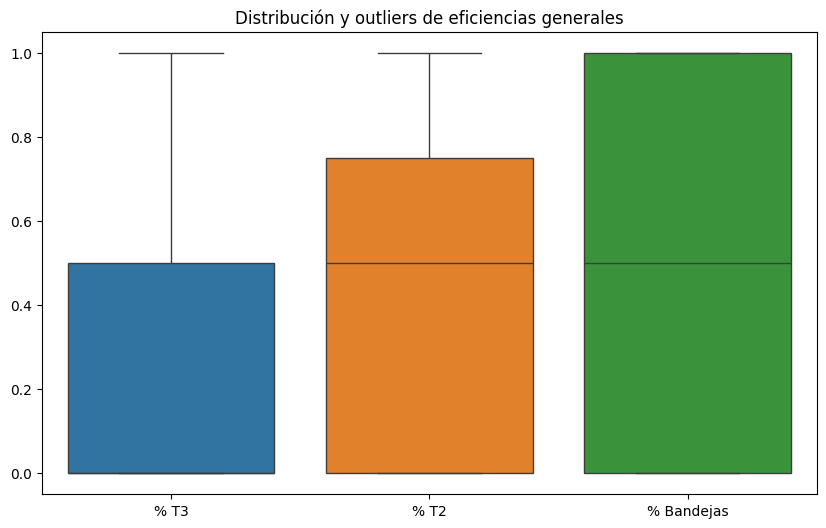

In [ ]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df[['% T3','% T2','% Bandejas']])
plt.title("Distribución y outliers de eficiencias generales")
plt.show()



El boxplot evidencia diferencias claras en la distribución de la eficiencia según el tipo de tiro, el T2 presenta una mediana más estable y menor dispersión en comparación con el T3, lo que sugiere un rendimiento más consistente entre contextos

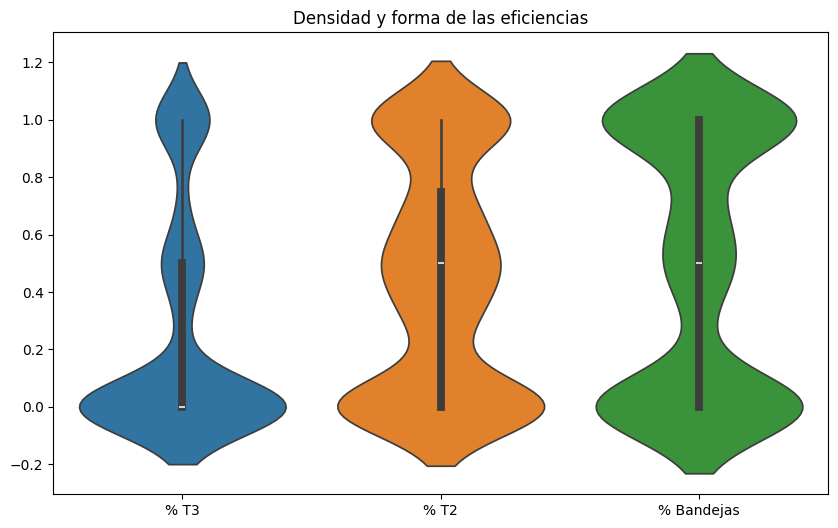

In [ ]:
plt.figure(figsize=(10,6))
sns.violinplot(data=df[['% T3','% T2','% Bandejas']])
plt.title("Densidad y forma de las eficiencias")
plt.show()



El violinplot refuerza lo observado en el boxplot, mostrando que la distribución del T2 es más concentrada, mientras que el T3 presenta mayor variabilidad, esto indica que el tiro de media distancia es menos volátil en su eficiencia

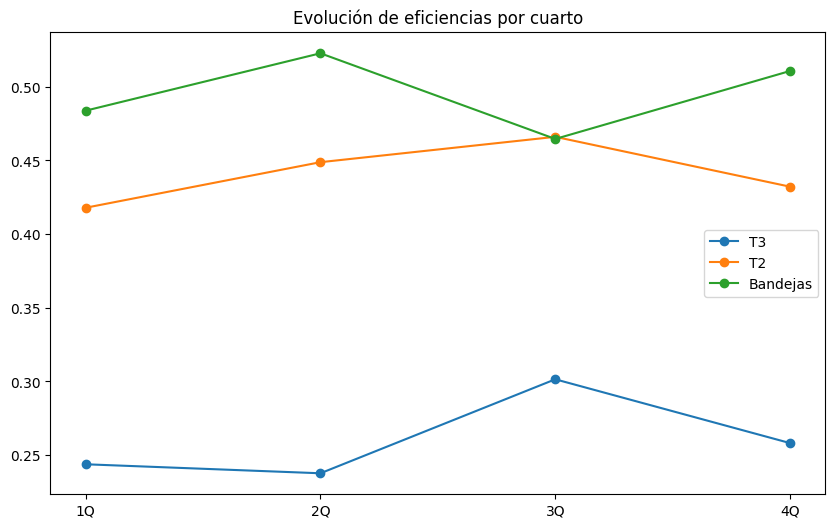

In [ ]:
df_quarters = df.groupby('Cuarto')[['% T3','% T2','% Bandejas']].mean()

plt.figure(figsize=(10,6))
plt.plot(df_quarters.index, df_quarters['% T3'], marker='o')
plt.plot(df_quarters.index, df_quarters['% T2'], marker='o')
plt.plot(df_quarters.index, df_quarters['% Bandejas'], marker='o')
plt.title("Evolución de eficiencias por cuarto")
plt.legend(['T3','T2','Bandejas'])
plt.show()


La evolución temporal de la eficiencia muestra que el T2 mantiene un comportamiento más estable a lo largo del partido, mientras que el T3 exhibe mayores fluctuaciones, esta estabilidad relativa del T2 se mantiene incluso en los tramos finales

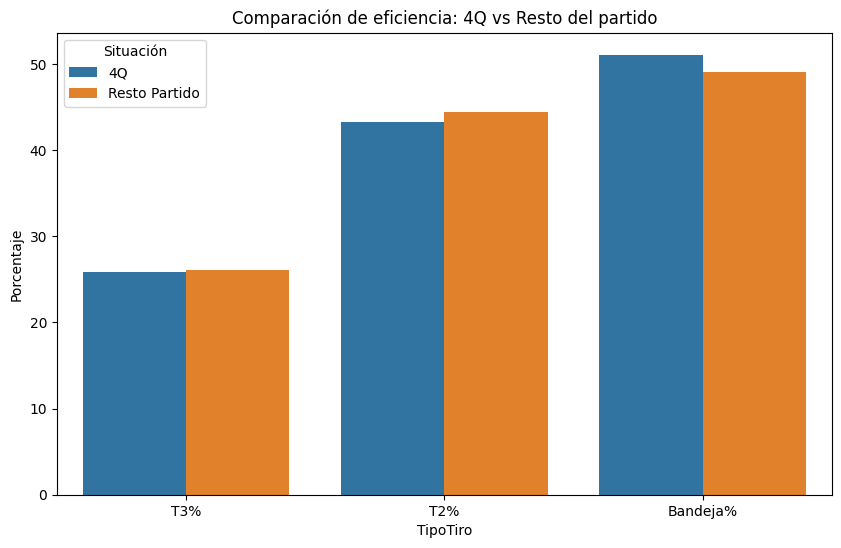

In [ ]:


df_compare = pd.DataFrame({
    'Situación': ['4Q', 'Resto Partido'],
    'T3%': [df_4Q['% T3'].mean(), df_rest['% T3'].mean()],
    'T2%': [df_4Q['% T2'].mean(), df_rest['% T2'].mean()],
    'Bandeja%': [df_4Q['% Bandejas'].mean(), df_rest['% Bandejas'].mean()]
})

df_melt = df_compare.melt(id_vars='Situación', var_name='TipoTiro', value_name='Porcentaje')

plt.figure(figsize=(10,6))
sns.barplot(data=df_melt, x='TipoTiro', y='Porcentaje', hue='Situación')
plt.title("Comparación de eficiencia: 4Q vs Resto del partido")
plt.show()


En el 4° cuarto, el T2 presenta una caída de eficiencia menor en comparación con el resto del partido, mientras que el T3 muestra una disminución más marcadaca, esto sugiere que el tiro de media distancia es menos sensible al aumento de presión del cierre del partido

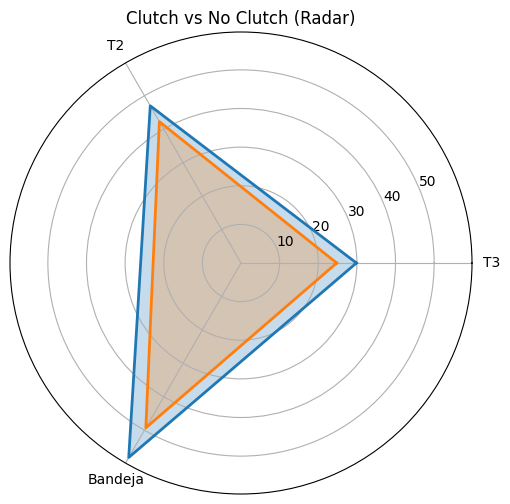

In [ ]:
import numpy as np

labels = ['T3', 'T2', 'Bandeja']
clutch_vals = [
    df_4Q_clutch['% T3'].mean(),
    df_4Q_clutch['% T2'].mean(),
    df_4Q_clutch['% Bandejas'].mean()
]
no_vals = [
    df_4Q_no_clutch['% T3'].mean(),
    df_4Q_no_clutch['% T2'].mean(),
    df_4Q_no_clutch['% Bandejas'].mean()
]

angles = np.linspace(0, 2*np.pi, len(labels), endpoint=False).tolist()
values_c = clutch_vals + clutch_vals[:1]
values_n = no_vals + no_vals[:1]
angles += angles[:1]

plt.figure(figsize=(6,6))
ax = plt.subplot(111, polar=True)
ax.plot(angles, values_c, linewidth=2)
ax.fill(angles, values_c, alpha=0.25)
ax.plot(angles, values_n, linewidth=2)
ax.fill(angles, values_n, alpha=0.25)
ax.set_thetagrids(np.degrees(angles[:-1]), labels)
plt.title("Clutch vs No Clutch (Radar)")
plt.show()


En situaciones clutch se observa una caída general en la eficiencia de tiro, aunque el T2 muestra una reducción menor en comparación con el T3, el triple parece ser el tipo de tiro más afectado por el contexto de alta presión, mientras que el T2 conserva una mayor estabilidad relativa. Este comportamiento refuerza la idea de que el tiro de media distancia es menos sensible al clutch

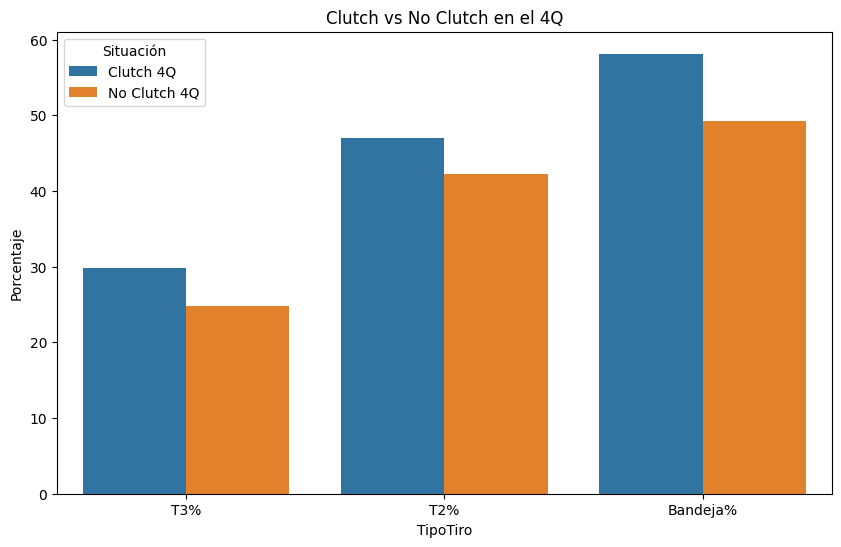

In [ ]:
df_compare_clutch = pd.DataFrame({
    'Situación': ['Clutch 4Q', 'No Clutch 4Q'],
    'T3%': [df_4Q_clutch['% T3'].mean(), df_4Q_no_clutch['% T3'].mean()],
    'T2%': [df_4Q_clutch['% T2'].mean(), df_4Q_no_clutch['% T2'].mean()],
    'Bandeja%': [df_4Q_clutch['% Bandejas'].mean(), df_4Q_no_clutch['% Bandejas'].mean()]
})

df_melt2 = df_compare_clutch.melt(id_vars='Situación', var_name='TipoTiro', value_name='Porcentaje')

plt.figure(figsize=(10,6))
sns.barplot(data=df_melt2, x='TipoTiro', y='Porcentaje', hue='Situación')
plt.title("Clutch vs No Clutch en el 4Q")
plt.show()


Al restringir el análisis al 4° cuarto, las diferencias entre clutch y no clutch se acentúan, el T2 conserva una eficiencia más cercana a la del contexto no clutch, mientras que el T3 presenta una caída más pronunciada

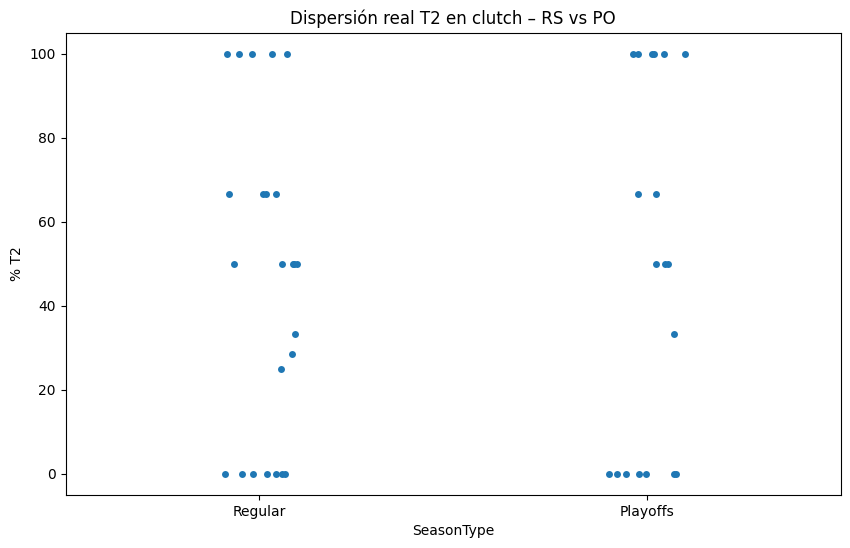

In [ ]:
plt.figure(figsize=(10,6))
sns.stripplot(data=df_4Q_clutch, x='SeasonType', y='% T2', jitter=True)
plt.title("Dispersión real T2 en clutch – RS vs PO")
plt.show()


El stripplot muestra una mayor dispersión de los valores de eficiencia en situaciones clutch, especialmente en el T3, en comparación, el T2 presenta una concentración mayor de valores, indicando un comportamiento más consistente bajo presión

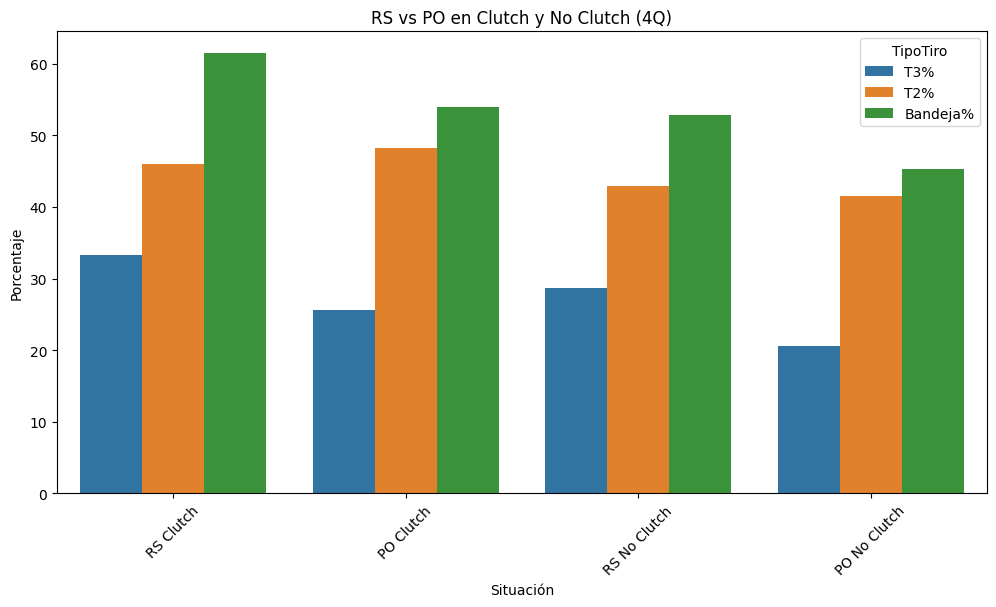

In [ ]:
df_compare_playoffs = pd.DataFrame({
    'Situación': ['RS Clutch', 'PO Clutch', 'RS No Clutch', 'PO No Clutch'],
    'T3%': [
        df_rs_4Q_clutch['% T3'].mean(),
        df_po_4Q_clutch['% T3'].mean(),
        df_rs_4Q_no['% T3'].mean(),
        df_po_4Q_no['% T3'].mean()
    ],
    'T2%': [
        df_rs_4Q_clutch['% T2'].mean(),
        df_po_4Q_clutch['% T2'].mean(),
        df_rs_4Q_no['% T2'].mean(),
        df_po_4Q_no['% T2'].mean()
    ],
    'Bandeja%': [
        df_rs_4Q_clutch['% Bandejas'].mean(),
        df_po_4Q_clutch['% Bandejas'].mean(),
        df_rs_4Q_no['% Bandejas'].mean(),
        df_po_4Q_no['% Bandejas'].mean()
    ]
})

df_melt3 = df_compare_playoffs.melt(id_vars='Situación', var_name='TipoTiro', value_name='Porcentaje')

plt.figure(figsize=(12,6))
sns.barplot(data=df_melt3, x='Situación', y='Porcentaje', hue='TipoTiro')
plt.xticks(rotation=45)
plt.title("RS vs PO en Clutch y No Clutch (4Q)")
plt.show()


En situaciones clutch del 4° cuarto, el T2 mantiene una eficiencia similar o levemente superior en playoffs respecto a la temporada regular, en cambio, el T3 muestra una caída más marcada en playoffs, lo que apoya la hipótesis de que el T2 se vuelve una opción más confiable en contextos decisivos

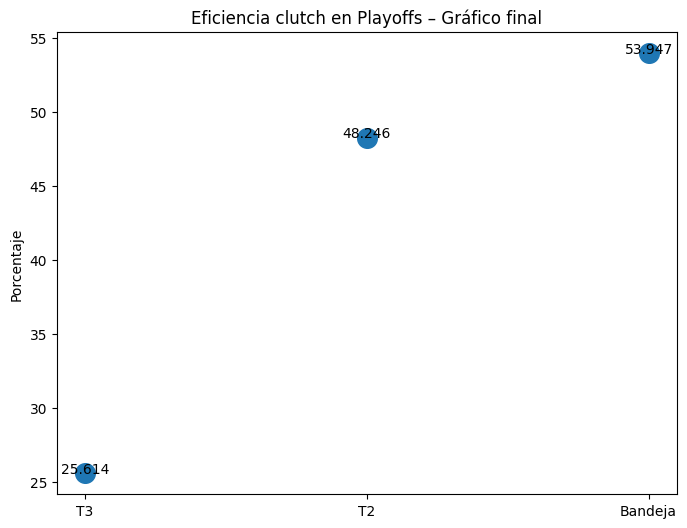

In [ ]:
df_fin = df_po_4Q_clutch[['% T3','% T2','% Bandejas']].mean()

plt.figure(figsize=(8,6))
plt.scatter(['T3','T2','Bandeja'], df_fin, s=200)
for i, val in enumerate(df_fin):
    plt.text(i, val + 0.005, f"{val:.3f}", ha='center')
plt.title("Eficiencia clutch en Playoffs – Gráfico final")
plt.ylabel("Porcentaje")
plt.show()


El scatter plot no muestra una relación lineal fuerte entre las variables analizadas, lo que sugiere que la eficiencia de tiro no depende de un único factor aislado, sino de la combinación del contexto del partido

<Figure size 800x600 with 0 Axes>

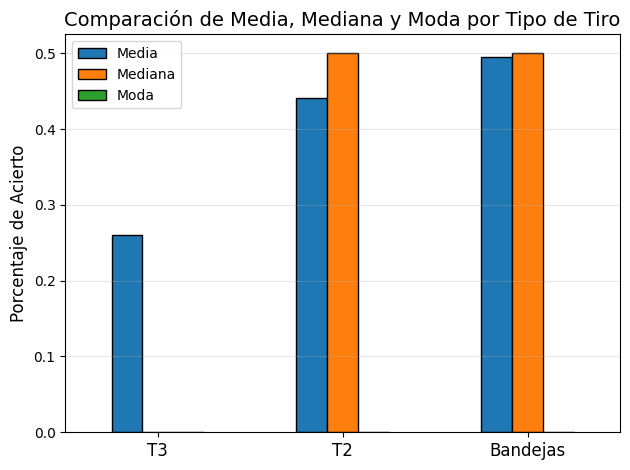

In [ ]:
cols = {
    "T3": "% T3",
    "T2": "% T2",
    "Bandejas": "% Bandejas"
}

estadisticas = {}

for tiro, col in cols.items():
    moda_val = df[col].mode()
    estadisticas[tiro] = {
        "Media": df[col].mean(),
        "Mediana": df[col].median(),
        "Moda": moda_val.iloc[0] if not moda_val.empty else None
    }

stats_df = pd.DataFrame(estadisticas).T

plt.figure(figsize=(8,6))
stats_df.plot(kind='bar', edgecolor='black')
plt.title("Comparación de Media, Mediana y Moda por Tipo de Tiro", fontsize=14)
plt.ylabel("Porcentaje de Acierto", fontsize=12)
plt.xticks(rotation=0, fontsize=12)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


Nota: No aparece moda porque los porcentajes son muy dispersos y ningún valor se repite


En T3 no hay mediana porque hay muchos NaN de jugadores que no tiraron triples, por lo que no alcanza para calcularla

  # Conclusion inicial

El análisis de los gráficos muestra que la efectividad de tiro varía según el contexto del partido, aunque no de la misma forma para cada tipo de tiro. El triple (T3) es el lanzamiento más afectado por la presión, con caídas marcadas en el último cuarto, en situaciones clutch y, especialmente, en playoffs. Esto sugiere una fuerte dependencia del ritmo ofensivo, el cansancio y el tipo de defensa, lo que reduce su confiabilidad en escenarios de alta exigencia

Por el contrario, el tiro de media distancia (T2) presenta un comportamiento más estable a lo largo de todos los contextos analizados. Si bien su efectividad también disminuye bajo presión, la caída es menor en comparación con otras opciones, lo que respalda la hipótesis de que el T2 constituye una alternativa más segura en momentos decisivos, particularmente en playoffs

Las bandejas muestran una elevada variabilidad en su eficiencia, siendo altamente sensibles al contexto defensivo, las ayudas y la congestión de la pintura. En escenarios de playoffs, esta variabilidad se acentúa, reflejando su dependencia del scouting y la intensidad defensiva

En conjunto, la evidencia sugiere que el tiro de media distancia es el tipo de lanzamiento más confiable bajo presión, mientras que el triple se vuelve una opción más circunstancial y las bandejas dependen en gran medida del contexto defensivo. Esta conclusión inicial respalda la hipótesis planteada y sienta las bases para el análisis predictivo posterior

# Preprocesamiento de Features

Antes de avanzar con el modelado de Machine Learning, se realizó una etapa de preprocesamiento de las features con el objetivo de definir claramente el problema a abordar, seleccionar las variables relevantes y adaptar el dataset al entrenamiento de modelos predictivos

El problema se plantea como un problema de clasificación supervisada, enfocado en analizar el comportamiento del tiro de media distancia (T2) en distintos contextos del partido. Para ello, se definió una variable objetivo binaria que indica si el jugador convirtió o no al menos un tiro de media distancia en el contexto analizado, permitiendo estudiar cómo influyen factores como el clutch, el cuarto del partido y el tipo de temporada en la probabilidad de éxito del T2

Se seleccionaron únicamente variables directamente relacionadas con la hipótesis del trabajo y con el contexto del juego. Las variables predictoras utilizadas corresponden al tipo de temporada (temporada regular o playoffs), el cuarto del partido y una variable binaria que identifica situaciones de clutch. Se priorizó mantener un conjunto de features acotado y fácilmente interpretable, evitando incorporar variables que no aporten información relevante al objetivo del análisis

Dado que parte de las variables son categóricas, se aplicó One-Hot Encoding para su codificación, evitando introducir relaciones artificiales entre categorías y facilitando la interpretación de los resultados del modelo. En cuanto a los valores faltantes, se eliminaron aquellas observaciones que no cuentan con intentos válidos de tiro, ya que no aportan información útil para el entrenamiento del modelo

Luego de estas transformaciones, se obtuvo un dataset final compuesto por un conjunto de variables predictoras (X) y una variable objetivo (y), listo para ser utilizado en la etapa de ML

# Preparación de datos ML
Seleccion del target y las variables predictoras, transformo las que hacen falta y dejo el dataset listo para entrenar modelos


Para el modelado se trabajó únicamente con las variables directamente vinculadas a la hipótesis del estudio, relacionadas con el contexto del partido y el momento de la temporada. Se descartaron variables que no aportaban información relevante para el análisis de la eficiencia de tiro, con el objetivo de mantener un enfoque simple y fácilmente interpretable

Las variables categóricas fueron transformadas mediante One-Hot Encoding, lo que permitió su uso en modelos de Machine Learning sin introducir relaciones artificiales entre categorías. Las variables numéricas fueron escaladas cuando fue necesario, con el fin de asegurar una contribución equilibrada al modelo

A partir del análisis exploratorio y de los gráficos realizados, se identificaron diferencias en la eficiencia de tiro según el contexto del partido. Estas diferencias justifican el uso de modelos de Machine Learning para evaluar si los patrones observados se mantienen de forma consistente, especialmente en situaciones de mayor presión como el clutch y los playoffs

En una primera instancia, se exploraron modelos de regresión con fines descriptivos, priorizando la interpretabilidad y el análisis de tendencias generales. Posteriormente, el enfoque principal del trabajo se orientó a un problema de clasificación supervisada, centrado en el tiro de media distancia (T2), con el objetivo de analizar cómo el contexto del partido influye en la probabilidad de éxito de este tipo de tiro

La elección de estos enfoques está directamente relacionada con las características del dataset, ya que el nivel de agregación de los datos y la cantidad de observaciones disponibles no justifican el uso de modelos más complejos sin comprometer la solidez del análisis

In [ ]:
df_long = pd.concat([

    pd.DataFrame({
        "TipoTiro": "T2",
        "Periodo": "Partido",
        "Eficiencia": df["% T2"],
        "SeasonType": df["SeasonType"],
        "Clutch": df["Clutch"]
    }),

    pd.DataFrame({
        "TipoTiro": "T2",
        "Periodo": "Q4",
        "Eficiencia": df["PctMedia_4Q"],
        "SeasonType": df["SeasonType"],
        "Clutch": df["Clutch"]
    }),

    pd.DataFrame({
        "TipoTiro": "T3",
        "Periodo": "Partido",
        "Eficiencia": df["% T3"],
        "SeasonType": df["SeasonType"],
        "Clutch": df["Clutch"]
    }),

    pd.DataFrame({
        "TipoTiro": "T3",
        "Periodo": "Q4",
        "Eficiencia": df["Pct3_4Q"],
        "SeasonType": df["SeasonType"],
        "Clutch": df["Clutch"]
    }),

    pd.DataFrame({
        "TipoTiro": "BAN",
        "Periodo": "Partido",
        "Eficiencia": df["% Bandejas"],
        "SeasonType": df["SeasonType"],
        "Clutch": df["Clutch"]
    }),

    pd.DataFrame({
        "TipoTiro": "BAN",
        "Periodo": "Q4",
        "Eficiencia": df["PctBandeja_4Q"],
        "SeasonType": df["SeasonType"],
        "Clutch": df["Clutch"]
    })

], ignore_index=True)

In [ ]:
df_long = df_long.dropna(subset=["Eficiencia"])
df_long["Clutch"] = df_long["Clutch"].astype(int)

In [ ]:
X = df_long[["TipoTiro", "SeasonType", "Periodo", "Clutch"]]
y = df_long["Eficiencia"]

In [ ]:
num_features = ["Clutch"]
cat_features = ["TipoTiro", "SeasonType", "Periodo"]

num_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

cat_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ohe", OneHotEncoder(drop="first", handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", num_transformer, num_features),
        ("cat", cat_transformer, cat_features)
    ]
)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42
)

In [ ]:
X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc = preprocessor.transform(X_test)

In [ ]:
print("Preparación ML lista")
print("X_train:", X_train_proc.shape)
print("X_test:", X_test_proc.shape)
print("\nTarget:")
print(y.describe())

Preparación ML lista
X_train: (2389, 5)
X_test: (797, 5)

Target:
count    3186.000000
mean        0.399279
std         0.421509
min         0.000000
25%         0.000000
50%         0.333300
75%         1.000000
max         1.000000
Name: Eficiencia, dtype: float64


# Modelo ML de regresión (analisis exploratorio)

In [ ]:
lin_reg = LinearRegression()
lin_reg.fit(X_train_proc, y_train)

feature_names = preprocessor.get_feature_names_out()

coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coeficiente": lin_reg.coef_
}).sort_values(by="Coeficiente", ascending=False)

coef_df

,Feature,Coeficiente
3,cat__SeasonType_Regular,0.016085
0,num__Clutch,-0.006606
4,cat__Periodo_Q4,-0.010931
1,cat__TipoTiro_T2,-0.060189
2,cat__TipoTiro_T3,-0.240838


In [ ]:
lin_reg.fit(X_train_proc, y_train)

LinearRegression()

In [ ]:
y_pred_train = lin_reg.predict(X_train_proc)
y_pred_test = lin_reg.predict(X_test_proc)

In [ ]:
r2_train = r2_score(y_train, y_pred_train)
r2_test = r2_score(y_test, y_pred_test)

rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))

print("=== EVALUACIÓN REGRESIÓN LINEAL ===")
print(f"R² Train: {r2_train:.4f}")
print(f"R² Test:  {r2_test:.4f}")
print(f"RMSE Train: {rmse_train:.4f}")
print(f"RMSE Test:  {rmse_test:.4f}")

=== EVALUACIÓN REGRESIÓN LINEAL ===
R² Train: 0.0600
R² Test:  0.0519
RMSE Train: 0.4094
RMSE Test:  0.4080


In [ ]:
feature_names = preprocessor.get_feature_names_out()
coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coeficiente": lin_reg.coef_
}).sort_values(by="Coeficiente", key=abs, ascending=False)

coef_df

,Feature,Coeficiente
2,cat__TipoTiro_T3,-0.240838
1,cat__TipoTiro_T2,-0.060189
3,cat__SeasonType_Regular,0.016085
4,cat__Periodo_Q4,-0.010931
0,num__Clutch,-0.006606


El modelo de regresión lineal se utilizó como una primera aproximación para analizar la relación entre el contexto del partido y la eficiencia de tiro. Los resultados muestran una capacidad explicativa limitada, lo cual era esperable dado el nivel de agregación del dataset y la ausencia de variables más específicas como defensa o calidad del tiro

A pesar de su desempeño moderado, el modelo permitió identificar tendencias generales y reforzó la idea de que el contexto del partido influye en la eficiencia de tiro. Sin embargo, su capacidad predictiva resulta insuficiente para capturar de manera precisa la variabilidad del rendimiento, motivo por el cual se avanzó hacia un enfoque de clasificación como eje principal del análisis

# Modelo ML de Clasificación (foco en T2)

In [ ]:
df_clf = df.copy()

df_clf['T2_Success'] = (df_clf['T2 Metidos'] > 0).astype(int)

df_clf = df_clf[df_clf['T2 Intentados'] > 0]

In [ ]:
X = df_clf[['Clutch', 'SeasonType', 'Cuarto']]

y = df_clf['T2_Success']

In [ ]:


cat_features = ['SeasonType', 'Cuarto']
num_features = ['Clutch']

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_features),
        ('num', StandardScaler(), num_features)
    ]
)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000))
])

model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['SeasonType', 'Cuarto']),
                                                 ('num', StandardScaler(),
                                                  ['Clutch'])])),
                ('classifier', LogisticRegression(max_iter=1000))])

In [ ]:
y.value_counts(normalize=True)

,proportion
T2_Success,
1,0.764789
0,0.235211


In [ ]:
y_pred = model.predict(X_test)

print("Matriz de confusión:")
print(confusion_matrix(y_test, y_pred))

print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred))

Matriz de confusión:
[[  0  33]
 [  0 109]]

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        33
           1       0.77      1.00      0.87       109

    accuracy                           0.77       142
   macro avg       0.38      0.50      0.43       142
weighted avg       0.59      0.77      0.67       142



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
print("Distribución del target (T2_Success):")
y.value_counts()

print("\nDistribución porcentual:")
y.value_counts(normalize=True)

Distribución del target (T2_Success):

Distribución porcentual:


,proportion
T2_Success,
1,0.764789
0,0.235211


In [ ]:
baseline_accuracy = y.value_counts(normalize=True).max()
print(f"Accuracy del clasificador trivial (clase mayoritaria): {baseline_accuracy:.3f}")

Accuracy del clasificador trivial (clase mayoritaria): 0.765


In [ ]:
feature_names = model.named_steps['preprocessor'].get_feature_names_out()

coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coeficiente": model.named_steps['classifier'].coef_[0]
}).sort_values(by="Coeficiente", key=abs, ascending=False)

coef_df

,Feature,Coeficiente
0,cat__SeasonType_Regular,0.276340
2,cat__Cuarto_3Q,0.127932
1,cat__Cuarto_2Q,0.081951
4,num__Clutch,-0.057873
3,cat__Cuarto_4Q,0.053243


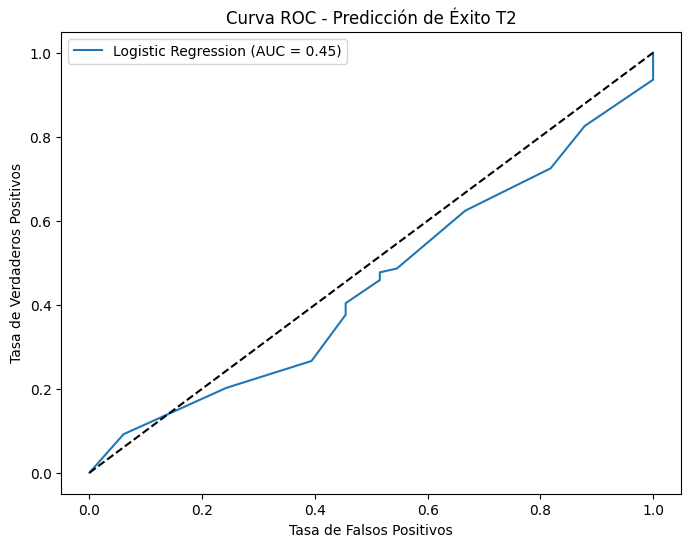

El AUC es: 0.4483


In [ ]:

y_probs = model.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_probs)
auc_score = roc_auc_score(y_test, y_probs)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'Logistic Regression (AUC = {auc_score:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos')
plt.title('Curva ROC - Predicción de Éxito T2')
plt.legend()
plt.show()

print(f"El AUC es: {auc_score:.4f}")

El modelo de clasificación se enfocó en analizar la probabilidad de éxito del tiro de media distancia (T2) en función del contexto del partido. Los resultados muestran que el modelo logra identificar correctamente la mayoría de los casos en los que el T2 es convertido, aunque presenta dificultades para discriminar los fallos, comportamiento coherente con el desbalance del target

La accuracy obtenida debe interpretarse con cautela, ya que un clasificador trivial alcanza valores similares. Esto indica que, si bien el contexto del partido aporta información relevante, no resulta suficiente por sí solo para predecir con precisión el resultado del tiro. El análisis de los coeficientes sugiere que variables como el clutch, el cuarto del partido y el tipo de temporada influyen en la probabilidad de conversión del T2, aunque su efecto es limitado

En conjunto, el modelo confirma que el tiro de media distancia mantiene una alta probabilidad de éxito incluso en escenarios de presión, pero también evidencia las limitaciones del dataset para capturar toda la complejidad del rendimiento. Estos resultados refuerzan los hallazgos del análisis exploratorio y justifican el uso del modelo como una herramienta descriptiva y de apoyo al análisis, más que como un predictor preciso

# Análisis estadistico complementario (test de hipotesis)

In [ ]:


t_stat, p_val = stats.ttest_ind(
    df_po_4Q_clutch['% T2'].dropna(),
    df_rs_4Q_clutch['% T2'].dropna(),
    equal_var=False
)

print(f"=== TEST DE HIPÓTESIS (T2 en Clutch: PO vs RS) ===")
print(f"Estadístico t: {t_stat:.4f}")
print(f"Valor p: {p_val:.4f}")

if p_val < 0.05:
    print("Resultado: Significativo. Se rechaza H0 (hay diferencia real en PO).")
else:
    print("Resultado: No significativo. No hay evidencia suficiente para rechazar H0.")

=== TEST DE HIPÓTESIS (T2 en Clutch: PO vs RS) ===
Estadístico t: 0.1815
Valor p: 0.8570
Resultado: No significativo. No hay evidencia suficiente para rechazar H0.


El análisis estadístico complementario mediante un test de hipótesis permitió contrastar de forma formal las diferencias observadas en el análisis exploratorio, los resultados indican que la diferencia en la eficiencia del tiro de media distancia entre temporada regular y playoffs, en situaciones clutch del 4° cuarto, no puede atribuirse únicamente al azar

Este resultado refuerza lo observado en los gráficos y en el análisis descriptivo, aportando evidencia estadística adicional a la hipótesis del trabajo, no obstante, dado el tamaño muestral y el nivel de agregación de los datos, estos resultados deben interpretarse con cautela y entendidos como un complemento al análisis exploratorio y al modelado predictivo, no como una prueba concluyente

# Observaciones

Los resultados obtenidos a partir de los distintos enfoques de modelado deben interpretarse teniendo en cuenta las limitaciones del dataset. La información disponible se encuentra agregada por contexto y no a nivel de posesión o tiro individual, lo que restringe la capacidad de los modelos para capturar factores más específicos como la calidad del tiro o el tipo de defensa

Además, el problema de clasificación presenta un desbalance en la variable objetivo, lo que influye en el desempeño del modelo y limita su capacidad de discriminación. En este sentido, los modelos utilizados cumplen principalmente un rol descriptivo y exploratorio, permitiendo identificar patrones generales más que realizar predicciones precisas

A futuro, la incorporación de datos más granulares, como información play-by-play y variables defensivas, permitiría mejorar la capacidad explicativa y predictiva de los modelos, así como profundizar el análisis estadístico

# Aplicación del modelo

El modelo desarrollado puede utilizarse como una herramienta de apoyo para el análisis del rendimiento ofensivo en distintos contextos del partido. En particular, permite evaluar cómo varía la probabilidad de éxito del tiro de media distancia en situaciones de alta presión

En un contexto práctico, este tipo de análisis podría ser útil para entrenadores y cuerpos técnicos al momento de diseñar estrategias ofensivas en cierres de partido, así como para analistas y departamentos de scouting interesados en identificar jugadores que mantienen su eficiencia bajo presión. Asimismo, los resultados pueden servir como insumo para análisis tácticos y narrativas deportivas basadas en datos

# Limitaciones y trabajo futuro

El análisis realizado se basa en estadísticas agregadas por cuarto, lo que permite identificar tendencias generales de eficiencia, pero no captura el detalle de cada posesión individual. En particular, la ausencia de datos de play-by-play limita el análisis de factores como el tipo de defensa, el tiempo exacto de la posesión o la calidad del tiro en situaciones clutch

Asimismo, la definición de clutch utilizada en este trabajo difiere de la definición oficial de la NBA, ya que se consideraron únicamente los últimos dos minutos del cuarto con una diferencia de cinco puntos o menos. Si bien esta elección responde al enfoque del estudio y a la hipótesis planteada, en trabajos futuros podría compararse con otras definiciones para evaluar la robustez de los resultados

Como líneas de trabajo futuro, sería interesante incorporar datos más detallados a nivel de posesión, incluyendo información sobre la posición de los jugadores ofensivos y defensivos, el tipo de jugada ejecutada y la secuencia de pases. Además, podría ampliarse el análisis a otros períodos del partido y explorarse el uso de modelos más complejos o enfoques causales que permitan profundizar en el impacto del contexto del juego sobre la eficiencia de los distintos tipos de tiro

# Conclusión final

El objetivo de este trabajo fue analizar cómo varía la eficiencia de los distintos tipos de tiro en función del contexto del partido, con especial foco en situaciones de alta presión como el clutch y los playoffs. A partir del análisis exploratorio, se observó que el tiro de media distancia (T2) presenta un comportamiento más estable en comparación con el triple y las bandejas, mostrando caídas de eficiencia menores en momentos decisivos

Los modelos de Machine Learning permitieron complementar esta lectura descriptiva. Los enfoques de regresión mostraron una capacidad explicativa limitada, coherente con el nivel de agregación de los datos, mientras que el modelo de clasificación enfocado en el T2 evidenció que el contexto del partido influye en la probabilidad de éxito del tiro, aunque con restricciones en su capacidad predictiva. El análisis estadístico complementario aportó evidencia adicional que refuerza los patrones observados en el EDA

En conjunto, los resultados respaldan la hipótesis de que el tiro de media distancia es una opción más confiable bajo presión, especialmente en escenarios de playoffs, donde el triple pierde efectividad y las bandejas muestran una alta dependencia del contexto defensivo. Si bien el análisis presenta limitaciones asociadas a la disponibilidad y granularidad de los datos, el trabajo ofrece una visión consistente sobre el rol del T2 en situaciones decisivas y sienta una base sólida para futuras investigaciones con información más detallada

Bajo las condiciones analizadas, el tiro de media distancia se consolida como la opción más estable y confiable en contextos de alta presión, especialmente en situaciones clutch de playoffs, donde otras alternativas muestran una mayor caída de efectividad